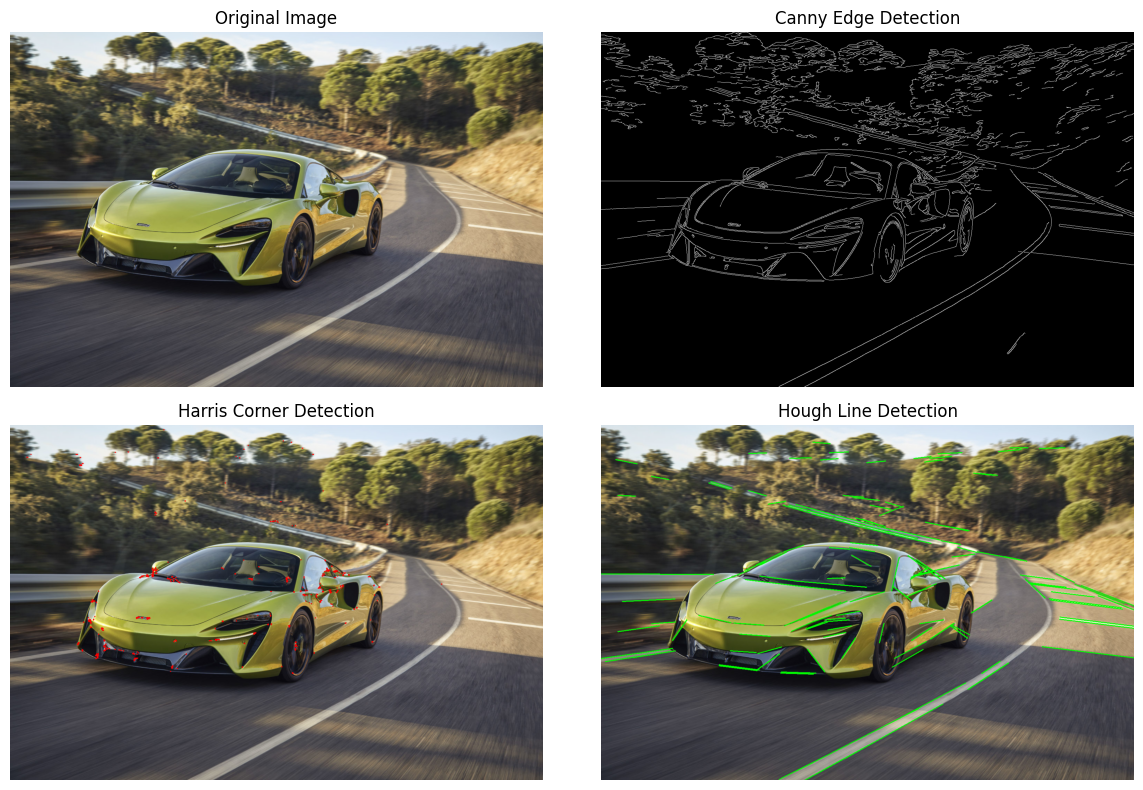

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
image = cv2.imread("test1.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# ---------------------------
# 1️⃣ EDGE DETECTION (CANNY)
# ---------------------------
blur = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blur, 50, 150)

# ---------------------------
# 2️⃣ CORNER DETECTION (HARRIS)
# ---------------------------
gray_float = np.float32(gray)
harris = cv2.cornerHarris(gray_float, 2, 3, 0.04)

harris = cv2.dilate(harris, None)
corner_image = image.copy()
corner_image[harris > 0.01 * harris.max()] = [0, 0, 255]

# ---------------------------
# 3️⃣ LINE DETECTION (HOUGH)
# ---------------------------
lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=100,
                        minLineLength=50, maxLineGap=10)

line_image = image.copy()
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_image, (x1, y1), (x2, y2), (0, 255, 0), 2)

# ---------------------------
# DISPLAY RESULTS
# ---------------------------
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(2,2,2)
plt.title("Canny Edge Detection")
plt.imshow(edges, cmap="gray")
plt.axis("off")

plt.subplot(2,2,3)
plt.title("Harris Corner Detection")
plt.imshow(cv2.cvtColor(corner_image, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(2,2,4)
plt.title("Hough Line Detection")
plt.imshow(cv2.cvtColor(line_image, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.tight_layout()
plt.show()
